<a href="https://colab.research.google.com/github/haskinse/bee2041_empirical_project/blob/main/source_code/04_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive # connect to google drive
drive.mount("/content/drive")

project_path = "/content/drive/MyDrive/bee2041_empirical_project" # define project path

Mounted at /content/drive


In [2]:
era_colours = { # a dictionary to match era to consistant colours
  "Taylor Swift": "#a4caa5", # green / teal
  "Fearless": "#f0c080", # yellow / gold
  "Speak Now": "#c7a8ca", # purple
  "Red": "#7a2e3a", # red
  "1989": "#b5e5f9", # light blue
  "Reputation": "#000000", # black
  "Lover": "#f6b0cc", # pink
  "Folklore": "#cdc9c0", # grey
  "Evermore": "#c5ac90", # brown
  "Midnights": "#1b4b7d", # navy
  "TTPD": "#e3dcdc", # white
  "The Life of a Showgirl": "#e15921" # orange
}

In [9]:
import matplotlib.pyplot as plt # library for data visualisation
import pandas as pd # library for data manipulation and tables
import seaborn as sns # used for statistical data visualisation
import sqlite3 # ibrary used to create and interact with SQLite databases

In [16]:
def plot_chart_performance(chart_peak, country, figure_name): # plot album chart performance for a given country

  conn = sqlite3.connect(f"{project_path}/data/clean/taylor_swift.db") # make a connection to SQLite database

  # retrieve album names and chart peak metric
  chart_performance = pd.read_sql(f"""
  SELECT album_id, album_name, {chart_peak} AS chart_peak
  FROM albums
  """, conn)

  # exclude Taylor’s Version albums to avoid doubling of eras
  chart_performance = chart_performance[~chart_performance["album_name"].str.contains("Taylor's Version", regex=False)]

  # replace long names with abbreviations for easier visualisation
  chart_performance["album_name"] = chart_performance["album_name"].replace({"The Tortured Poets Department": "TTPD"})
  chart_performance["album_name"] = chart_performance["album_name"].replace({"The Life of a Showgirl": "Life of a Showgirl"})

  base_colours = chart_performance["album_name"].astype(str).map(era_colours).fillna("#cccccc") # assign consistent colours to each era

  sns.reset_defaults()

  plt.figure(figsize = (8, 6)) # set figure size

  plt.plot(chart_performance["album_name"], chart_performance["chart_peak"], color = "grey", linestyle = "--") # plot a trend line across eras

  plt.scatter(chart_performance["album_name"], chart_performance["chart_peak"], color = base_colours) # add scatter points coloured by era

  plt.xticks(rotation = 45, ha = "right") # rotate labels for readability

  # label the axes and title
  plt.xlabel("Era")
  plt.ylabel("Chart Peak")
  plt.title(f"{country} Chart Peaks by Era")

  lowest_peak = chart_performance["chart_peak"].max() # find the worst chart position

  if lowest_peak < 10:
    offset = 0.1 # use small label offset when values are across a small scale

  else:
    offset = 2 # use larger offset when values are more spread out

  # annotate each point with its chart peak value
  for i, row in chart_performance.iterrows():
    plt.text(row["album_name"], row["chart_peak"] - offset, str(row["chart_peak"]), fontsize = 9, ha = "center")

  # remove unnecessary borders for cleaner visualisation
  plt.gca().spines["top"].set_visible(False)
  plt.gca().spines["right"].set_visible(False)

  plt.gca().invert_yaxis() # swap the axis so rank 1 is at the top

  sns.reset_defaults()

  plt.savefig(f"{project_path}/output/figures/{figure_name}.png", dpi=300, bbox_inches="tight")

  plt.tight_layout()
  plt.show() # show the final chart

  conn.close() # close database connection

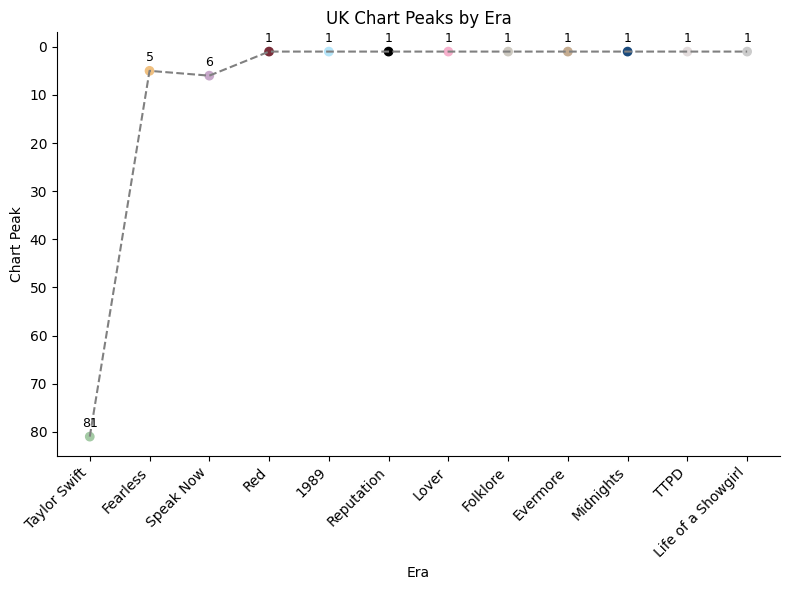

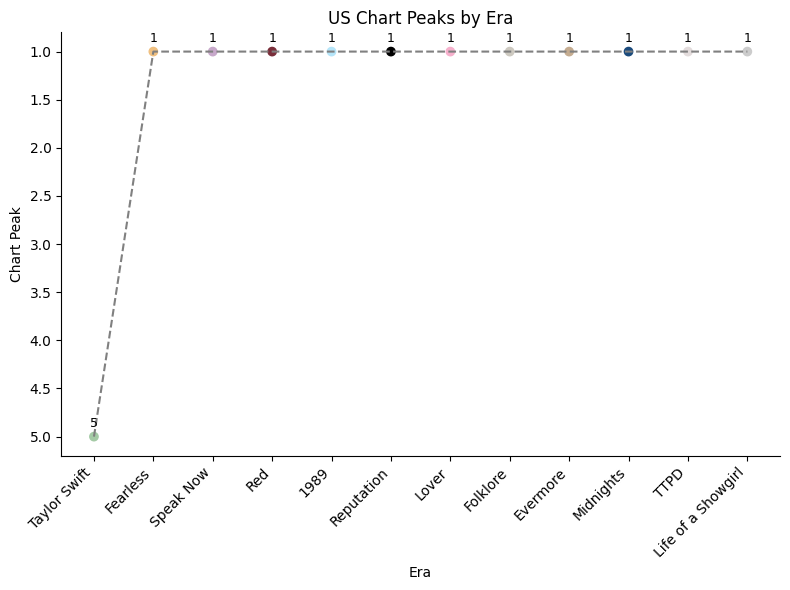

In [17]:
plot_chart_performance("uk_peak", "UK", "uk_chart_performance") # plot the chart performance of Taylor Swift eras in the UK

plot_chart_performance("us_peak", "US", "us_chart_performance") # plot the chart performance of Taylor Swift eras in the US